# Laboratorio: Problema Bancario
## Simulación de Sistemas de Colas M/M/1

### Presentado por:
Jorge Paniagua

### Herramienta utilizada:
Google Colab - Python

### Objetivo
Analizar el comportamiento del sistema de atención bancaria mediante simulación de eventos discretos y teoría de colas M/M/1.

# Introducción

El Banco de Colombia desea optimizar el funcionamiento de sus cajeros para operaciones de pagos, consignaciones y retiros.

Actualmente el banco dispone de 3 cajas de atención y necesita determinar cuál es la mejor configuración para reducir los tiempos de espera de los clientes.

Para resolver el problema se implementará una simulación basada en teoría de colas M/M/1 utilizando distribuciones exponenciales para modelar:
- tiempos entre llegadas,
- tiempos de servicio,
- comportamiento estocástico del sistema.

La simulación permitirá analizar diferentes escenarios de atención y apoyar la toma de decisiones sobre:
- distribución de cajeros,
- necesidad de nuevos servidores,
- tiempos promedio de espera,
- desempeño general del sistema.

# Objetivos

## Objetivo General
Simular el sistema bancario utilizando teoría de colas M/M/1 para evaluar el desempeño de los cajeros.

## Objetivos Específicos

- Simular 10 réplicas independientes del sistema.
- Identificar el cajero con menor y mayor tiempo de atención.
- Calcular el promedio de usuarios por tipo.
- Analizar tiempos de espera y tiempos de servicio.
- Evaluar la necesidad de agregar un nuevo cajero.
- Comparar diferentes configuraciones de atención.

In [40]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from collections import deque

# Configuración visual
plt.rcParams["figure.figsize"] = (10,5)

# Parámetros del Sistema

El modelo utiliza los datos suministrados en el laboratorio:

- 70% de usuarios realizan retiros.
- 30% realizan pagos o consignaciones.
- El banco opera durante 8 horas diarias.
- Los tiempos siguen distribuciones exponenciales.
- Se realizarán 10 réplicas independientes.

In [16]:
# ==========================================
# PARÁMETROS DEL SISTEMA
# ==========================================

HORAS_OPERACION = 8
TIEMPO_SIMULACION = HORAS_OPERACION * 60

NUM_REPLICAS = 10

# Probabilidades generales
PROB_RETIRO = 0.70
PROB_PAGO = 0.30

# Tipos de usuario
TIPOS = [
    "Rapido",
    "Normal",
    "Lento",
    "Muy lento"
]

# ==========================================
# PROBABILIDADES
# ==========================================

PROB_RETIRO_TIPO = [0.23, 0.40, 0.17, 0.20]

PROB_PAGO_TIPO = [0.10, 0.20, 0.30, 0.40]

# ==========================================
# TIEMPOS PROMEDIO
# ==========================================

# RETIROS
SERVICIO_RETIRO = [1, 2, 3, 4]
LLEGADA_RETIRO = [1, 2, 3, 3]

# PAGOS
SERVICIO_PAGO = [3, 3, 5, 7]
LLEGADA_PAGO = [1, 2, 3, 4]

# Supuestos del Modelo

Para el desarrollo de la simulación se consideraron los siguientes supuestos:

- Los clientes llegan de manera aleatoria.
- Los tiempos entre llegadas siguen distribución exponencial.
- Los tiempos de servicio siguen distribución exponencial.
- Cada cajero atiende un cliente a la vez.
- La disciplina de atención es FIFO.
- El desplazamiento dentro del banco es despreciable.
- Todos los clientes esperan hasta ser atendidos.
- Cada réplica utiliza una semilla distinta.

In [17]:
# ==========================================
# FUNCIONES AUXILIARES
# ==========================================

def exponencial(media):
    return np.random.exponential(media)

# ------------------------------------------

def generar_tipo_operacion():

    if np.random.random() < PROB_RETIRO:
        return "Retiro"

    return "Pago"

# ------------------------------------------

def generar_tipo_usuario(tipo_operacion):

    if tipo_operacion == "Retiro":

        return np.random.choice(
            TIPOS,
            p=PROB_RETIRO_TIPO
        )

    return np.random.choice(
        TIPOS,
        p=PROB_PAGO_TIPO
    )

# ------------------------------------------

def obtener_tiempos(
    tipo_operacion,
    tipo_usuario
):

    idx = TIPOS.index(tipo_usuario)

    if tipo_operacion == "Retiro":

        return (
            LLEGADA_RETIRO[idx],
            SERVICIO_RETIRO[idx]
        )

    return (
        LLEGADA_PAGO[idx],
        SERVICIO_PAGO[idx]
    )

# Descripción del Modelo de Simulación

El sistema se modeló utilizando simulación de eventos discretos.

Cada cliente:
1. llega al banco,
2. se clasifica como retiro o pago,
3. recibe una categoría de velocidad,
4. es asignado al cajero disponible más cercano.

Para cada cliente se calculan:
- tiempo de llegada,
- tiempo de espera,
- tiempo de servicio,
- tiempo total en el sistema.

Los valores se almacenan para realizar posteriormente el análisis estadístico.

In [18]:
# ==========================================
# SIMULACIÓN PRINCIPAL
# ==========================================

def simular_banco(
    num_cajeros=3,
    tiempo_simulacion=480,
    semilla=None
):

    if semilla is not None:
        np.random.seed(semilla)

    cajeros_libres = [0] * num_cajeros

    registros = []

    tiempo_actual = 0

    while tiempo_actual < tiempo_simulacion:

        # ----------------------------------
        # GENERAR CLIENTE
        # ----------------------------------

        tipo_operacion = generar_tipo_operacion()

        tipo_usuario = generar_tipo_usuario(
            tipo_operacion
        )

        media_llegada, media_servicio = obtener_tiempos(
            tipo_operacion,
            tipo_usuario
        )

        tiempo_entre_llegadas = exponencial(
            media_llegada
        )

        tiempo_actual += tiempo_entre_llegadas

        if tiempo_actual > tiempo_simulacion:
            break

        # ----------------------------------
        # ASIGNACIÓN DE CAJERO
        # ----------------------------------

        cajero = np.argmin(cajeros_libres)

        inicio_servicio = max(
            tiempo_actual,
            cajeros_libres[cajero]
        )

        tiempo_espera = (
            inicio_servicio - tiempo_actual
        )

        tiempo_servicio = exponencial(
            media_servicio
        )

        fin_servicio = (
            inicio_servicio + tiempo_servicio
        )

        cajeros_libres[cajero] = fin_servicio

        registros.append({

            "TipoOperacion": tipo_operacion,
            "TipoUsuario": tipo_usuario,
            "TiempoLlegada": tiempo_actual,
            "InicioServicio": inicio_servicio,
            "FinServicio": fin_servicio,
            "TiempoEspera": tiempo_espera,
            "TiempoServicio": tiempo_servicio,
            "TiempoSistema": (
                tiempo_espera + tiempo_servicio
            ),
            "Cajero": cajero + 1

        })

    return pd.DataFrame(registros)

# Prueba Inicial del Modelo

Se ejecuta una simulación preliminar para validar el funcionamiento del sistema.

In [19]:
df_prueba = simular_banco()

df_prueba.head()

,TipoOperacion,TipoUsuario,TiempoLlegada,InicioServicio,FinServicio,TiempoEspera,TiempoServicio,TiempoSistema,Cajero
0,Pago,Normal,2.099975,2.099975,7.604924,0.0,5.504949,5.504949,1
1,Pago,Muy lento,6.166655,6.166655,14.589282,0.0,8.422626,8.422626,2
2,Retiro,Normal,9.392516,9.392516,11.759606,0.0,2.367089,2.367089,3
3,Retiro,Normal,11.842862,11.842862,16.066547,0.0,4.223685,4.223685,1
4,Pago,Lento,17.547777,17.547777,17.856562,0.0,0.308785,0.308785,3


# Ejecución de Réplicas

Para obtener resultados estadísticamente representativos se ejecutan 10 réplicas independientes del sistema.

Cada réplica utiliza:
- la misma configuración,
- diferentes números aleatorios,
- distintas secuencias de llegadas y servicios.

In [20]:
# ==========================================
# EJECUCIÓN DE RÉPLICAS
# ==========================================

resultados_replicas = []

for replica in range(NUM_REPLICAS):

    df = simular_banco(
        num_cajeros=3,
        tiempo_simulacion=TIEMPO_SIMULACION,
        semilla=replica
    )

    df["Replica"] = replica + 1

    resultados_replicas.append(df)

# ==========================================
# UNIR RESULTADOS
# ==========================================

resultados = pd.concat(
    resultados_replicas,
    ignore_index=True
)

print("Total de registros generados:")
print(len(resultados))

Total de registros generados:
2018


# Visualización General de Datos

A continuación se muestran algunos registros generados por la simulación.

In [21]:
resultados.head(10)

,TipoOperacion,TipoUsuario,TiempoLlegada,InicioServicio,FinServicio,TiempoEspera,TiempoServicio,TiempoSistema,Cajero,Replica
0,Retiro,Lento,2.769669,2.769669,5.131273,0.000000,2.361603,2.361603,1,1
1,Retiro,Lento,4.496227,4.496227,11.166800,0.000000,6.670573,6.670573,2,1
2,Pago,Lento,9.202915,9.202915,12.966286,0.000000,3.763371,3.763371,3,1
3,Retiro,Muy lento,9.423972,9.423972,9.788616,0.000000,0.364644,0.364644,1,1
4,Retiro,Muy lento,13.941324,13.941324,22.102581,0.000000,8.161257,8.161257,1,1
5,Pago,Muy lento,16.417042,16.417042,27.032794,0.000000,10.615752,10.615752,2,1
6,Retiro,Lento,16.881231,16.881231,25.564492,0.000000,8.683261,8.683261,3,1
7,Retiro,Normal,17.495792,22.102581,25.079091,4.606790,2.976510,7.583299,1,1
8,Retiro,Normal,17.533729,25.079091,27.001853,7.545362,1.922762,9.468124,1,1
9,Retiro,Normal,23.289559,25.564492,27.854770,2.274933,2.290278,4.565211,3,1


# Punto 1
# Cajero con Menor y Mayor Tiempo Promedio de Atención

Se calcula el tiempo promedio de servicio de cada cajero para identificar:
- el cajero más rápido,
- el cajero más lento.

In [22]:
# ==========================================
# TIEMPO PROMEDIO POR CAJERO
# ==========================================

tiempos_cajero = resultados.groupby(
    "Cajero"
)["TiempoServicio"].mean()

print(tiempos_cajero)

print("\nCajero más rápido:")
print(tiempos_cajero.idxmin())

print("\nCajero más lento:")
print(tiempos_cajero.idxmax())

Cajero
1    3.241160
2    3.155924
3    3.127881
Name: TiempoServicio, dtype: float64

Cajero más rápido:
3

Cajero más lento:
1


# Gráfica de Tiempos Promedio por Cajero

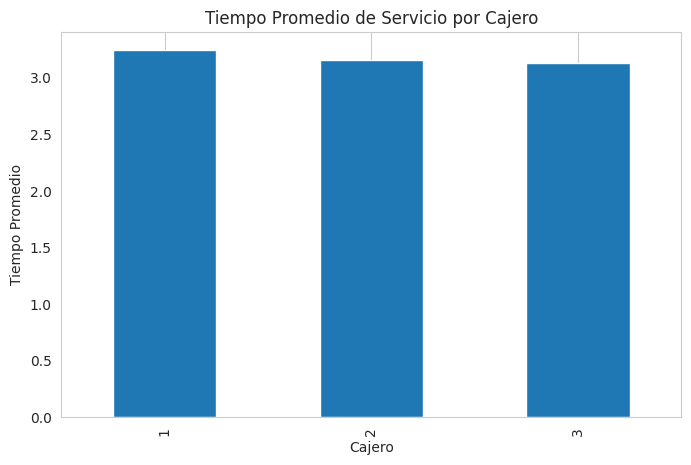

In [41]:
plt.figure(figsize=(8,5))

tiempos_cajero.plot(kind="bar")

plt.title("Tiempo Promedio de Servicio por Cajero")
plt.xlabel("Cajero")
plt.ylabel("Tiempo Promedio")

plt.grid(axis="y")

plt.show()

# Punto 2
# Promedio de Usuarios por Tipo

Se calcula el promedio de usuarios:
- rápidos,
- normales,
- lentos,
- muy lentos,

considerando todas las réplicas realizadas.

In [24]:
# ==========================================
# PROMEDIO DE USUARIOS POR TIPO
# ==========================================

usuarios_replica = resultados.groupby(
    ["Replica", "TipoOperacion", "TipoUsuario"]
).size().reset_index(name="Cantidad")

promedio_usuarios = usuarios_replica.groupby(
    ["TipoOperacion", "TipoUsuario"]
)["Cantidad"].mean()

print(promedio_usuarios)

TipoOperacion  TipoUsuario
Pago           Lento          19.2
               Muy lento      24.2
               Normal         11.7
               Rapido          5.0
Retiro         Lento          24.1
               Muy lento      27.1
               Normal         59.4
               Rapido         31.1
Name: Cantidad, dtype: float64


# Distribución Promedio de Usuarios

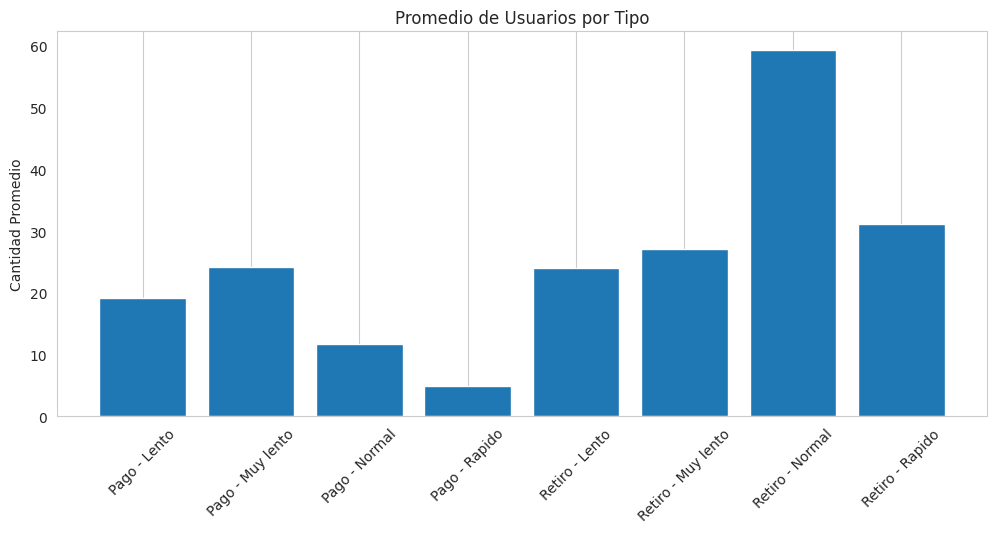

In [42]:
grafica_usuarios = promedio_usuarios.reset_index()

labels = (
    grafica_usuarios["TipoOperacion"]
    + " - "
    + grafica_usuarios["TipoUsuario"]
)

plt.figure(figsize=(12,5))

plt.bar(
    labels,
    grafica_usuarios["Cantidad"]
)

plt.xticks(rotation=45)

plt.title("Promedio de Usuarios por Tipo")
plt.ylabel("Cantidad Promedio")

plt.grid(axis="y")

plt.show()

# Punto 3
# Total de Usuarios por Réplica

Se analiza el total de usuarios por tipo en cada una de las réplicas ejecutadas.

In [26]:
usuarios_replica

,Replica,TipoOperacion,TipoUsuario,Cantidad
0,1,Pago,Lento,18
1,1,Pago,Muy lento,24
2,1,Pago,Normal,8
3,1,Pago,Rapido,5
4,1,Retiro,Lento,16
...,...,...,...,...
75,10,Pago,Rapido,7
76,10,Retiro,Lento,21
77,10,Retiro,Muy lento,31
78,10,Retiro,Normal,60


# Réplica con Menor Cantidad de Usuarios por Tipo

In [27]:
menores = usuarios_replica.loc[
    usuarios_replica.groupby(
        ["TipoOperacion", "TipoUsuario"]
    )["Cantidad"].idxmin()
]

menores

,Replica,TipoOperacion,TipoUsuario,Cantidad
64,9,Pago,Lento,14
73,10,Pago,Muy lento,20
18,3,Pago,Normal,7
19,3,Pago,Rapido,2
4,1,Retiro,Lento,16
53,7,Retiro,Muy lento,20
38,5,Retiro,Normal,43
63,8,Retiro,Rapido,22


# Punto 4
# Evaluación de Necesidad de Nuevo Cajero

Se analizan:
- tiempos promedio de espera,
- tiempos en sistema,
- saturación del servicio,

para determinar si es necesario agregar un nuevo cajero.

Los resultados obtenidos muestran que el sistema con 3 cajeros mixtos mantiene tiempos de espera relativamente bajos, con un promedio aproximado de 0.43 minutos.

Sin embargo, al reducir la cantidad de cajeros a 2, el tiempo promedio de espera aumenta considerablemente hasta 2.85 minutos, evidenciando congestión y mayor saturación del sistema.

Por otro lado, al aumentar la cantidad de cajeros a 4, el tiempo promedio de espera disminuye a aproximadamente 0.08 minutos, mejorando significativamente el desempeño general del sistema.

Con base en los resultados obtenidos, se concluye que aumentar la cantidad de cajeros mejora la capacidad de atención y reduce la congestión del sistema bancario.

In [28]:
# ==========================================
# MÉTRICAS DEL SISTEMA
# ==========================================

espera_promedio = resultados[
    "TiempoEspera"
].mean()

servicio_promedio = resultados[
    "TiempoServicio"
].mean()

sistema_promedio = resultados[
    "TiempoSistema"
].mean()

print("Tiempo promedio de espera:")
print(round(espera_promedio, 2))

print("\nTiempo promedio de servicio:")
print(round(servicio_promedio, 2))

print("\nTiempo promedio en el sistema:")
print(round(sistema_promedio, 2))

Tiempo promedio de espera:
0.43

Tiempo promedio de servicio:
3.17

Tiempo promedio en el sistema:
3.6


#  Distribución de Tiempos de Espera

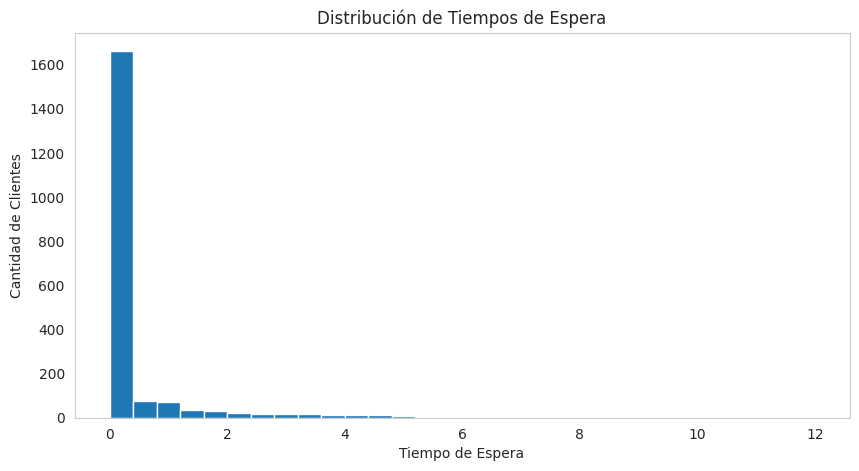

In [43]:
plt.figure(figsize=(10,5))

plt.hist(
    resultados["TiempoEspera"],
    bins=30
)

plt.title("Distribución de Tiempos de Espera")
plt.xlabel("Tiempo de Espera")
plt.ylabel("Cantidad de Clientes")

plt.grid()

plt.show()

# Variabilidad de los Tiempos de Espera

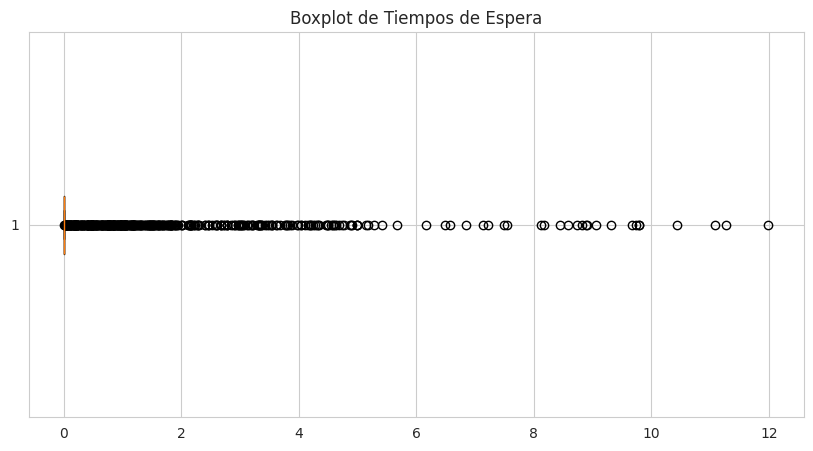

In [44]:
plt.figure(figsize=(10,5))

plt.boxplot(
    resultados["TiempoEspera"],
    vert=False
)

plt.title("Boxplot de Tiempos de Espera")

plt.show()

Se compararon diferentes configuraciones de cajeros con el objetivo de analizar el comportamiento del sistema bancario bajo distintos niveles de capacidad de atención.

Los escenarios evaluados fueron:

1. 3 cajeros mixtos
2. 2 cajeros mixtos
3. 4 cajeros mixtos

La comparación se realizó utilizando:
- tiempo promedio de espera,
- tiempo promedio de servicio,
- tiempo promedio en el sistema,
- cantidad de clientes atendidos.

Los resultados permitieron identificar el impacto que tiene la cantidad de cajeros sobre la congestión y eficiencia del sistema.

In [31]:
# ==========================================
# FUNCIÓN GENERAL DE ESCENARIOS
# ==========================================

def ejecutar_escenario(
    nombre,
    num_cajeros,
    replicas=10
):

    resultados_escenario = []

    for replica in range(replicas):

        df = simular_banco(
            num_cajeros=num_cajeros,
            tiempo_simulacion=TIEMPO_SIMULACION,
            semilla=replica
        )

        resultados_escenario.append(df)

    datos = pd.concat(
        resultados_escenario,
        ignore_index=True
    )

    return {

        "Escenario": nombre,

        "Cajeros": num_cajeros,

        "ClientesAtendidos": len(datos),

        "EsperaPromedio": datos[
            "TiempoEspera"
        ].mean(),

        "ServicioPromedio": datos[
            "TiempoServicio"
        ].mean(),

        "SistemaPromedio": datos[
            "TiempoSistema"
        ].mean()
    }

# Ejecución de Escenarios

Se ejecutan múltiples configuraciones para comparar el desempeño del sistema bancario.

In [32]:
# ==========================================
# ESCENARIOS
# ==========================================

escenario_1 = ejecutar_escenario(
    "3 Cajeros Mixtos",
    3
)

escenario_2 = ejecutar_escenario(
    "2 Cajeros",
    2
)

escenario_3 = ejecutar_escenario(
    "4 Cajeros",
    4
)

# ==========================================
# TABLA COMPARATIVA
# ==========================================

comparacion = pd.DataFrame([
    escenario_1,
    escenario_2,
    escenario_3
])

comparacion

,Escenario,Cajeros,ClientesAtendidos,EsperaPromedio,ServicioPromedio,SistemaPromedio
0,3 Cajeros Mixtos,3,2018,0.425735,3.174463,3.600199
1,2 Cajeros,2,2018,2.847381,3.174463,6.021845
2,4 Cajeros,4,2018,0.083216,3.174463,3.257679


# Comparación de Métricas

In [33]:
comparacion.round(2).style.background_gradient(cmap="Blues")

,Escenario,Cajeros,ClientesAtendidos,EsperaPromedio,ServicioPromedio,SistemaPromedio
0,3 Cajeros Mixtos,3,2018,0.43,3.17,3.60
1,2 Cajeros,2,2018,2.85,3.17,6.02
2,4 Cajeros,4,2018,0.08,3.17,3.26


# Tiempo Promedio de Espera por Escenario

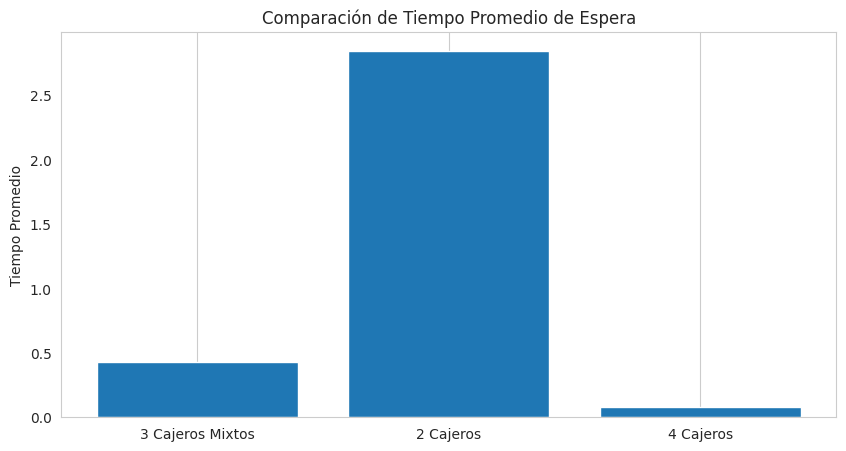

In [45]:
plt.figure(figsize=(10,5))

plt.bar(
    comparacion["Escenario"],
    comparacion["EsperaPromedio"]
)

plt.title(
    "Comparación de Tiempo Promedio de Espera"
)

plt.ylabel("Tiempo Promedio")

plt.grid(axis="y")

plt.show()

# Tiempo Promedio en el Sistema

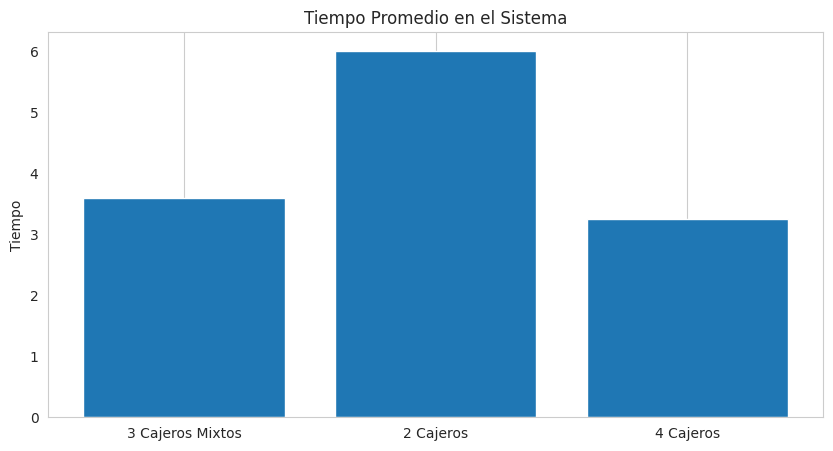

In [46]:
plt.figure(figsize=(10,5))

plt.bar(
    comparacion["Escenario"],
    comparacion["SistemaPromedio"]
)

plt.title(
    "Tiempo Promedio en el Sistema"
)

plt.ylabel("Tiempo")

plt.grid(axis="y")

plt.show()

#  Cantidad de Clientes Atendidos

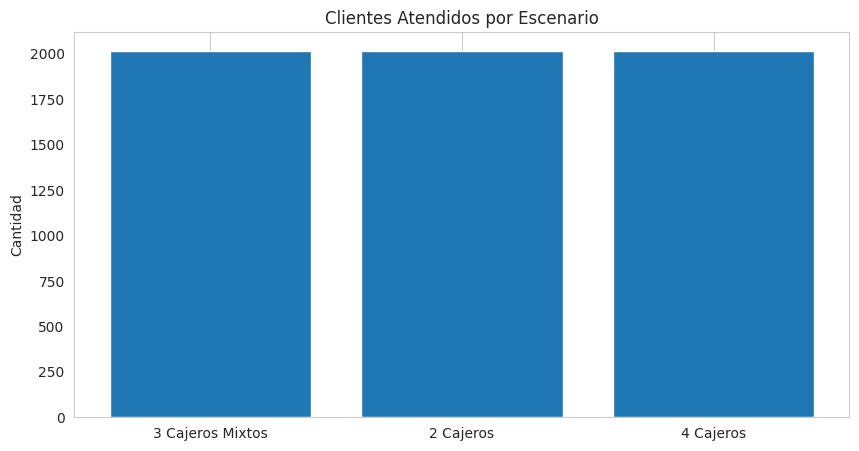

In [47]:
plt.figure(figsize=(10,5))

plt.bar(
    comparacion["Escenario"],
    comparacion["ClientesAtendidos"]
)

plt.title(
    "Clientes Atendidos por Escenario"
)

plt.ylabel("Cantidad")

plt.grid(axis="y")

plt.show()

# Conclusiones

## Conclusión 1
El escenario con 4 cajeros presentó el mejor desempeño del sistema, obteniendo el menor tiempo promedio de espera con un valor aproximado de 0.08 minutos. Esto demuestra que aumentar la cantidad de servidores reduce significativamente la congestión y mejora la atención al cliente.

## Conclusión 2
El escenario con únicamente 2 cajeros presentó el peor desempeño, alcanzando un tiempo promedio de espera cercano a 2.85 minutos y un tiempo promedio en el sistema de 6.02 minutos. Esto evidencia una mayor saturación del sistema debido a la reducción de capacidad de atención.

## Conclusión 3
La configuración actual de 3 cajeros mixtos mostró un comportamiento estable, con un tiempo promedio de espera de aproximadamente 0.43 minutos y un tiempo promedio total en el sistema de 3.60 minutos, permitiendo atender adecuadamente la demanda simulada.

## Conclusión 4
El tiempo promedio de servicio se mantuvo cercano a 3.17 minutos en todos los escenarios, lo que indica que las variaciones observadas en los tiempos de espera dependen principalmente de la cantidad de cajeros disponibles y no del tiempo de atención individual.

## Conclusión 5
La simulación mediante teoría de colas permitió analizar de forma objetiva el comportamiento del sistema bancario, facilitando la comparación entre escenarios y apoyando la toma de decisiones respecto a la distribución y cantidad de cajeros requeridos.

# Exportación de Resultados

In [37]:
with pd.ExcelWriter(
    "resultados_banco.xlsx"
) as writer:

    resultados.to_excel(
        writer,
        sheet_name="Simulacion",
        index=False
    )

    comparacion.to_excel(
        writer,
        sheet_name="Comparacion",
        index=False
    )

print("Archivo Excel generado correctamente.")

Archivo Excel generado correctamente.


In [38]:
from google.colab import files

files.download("resultados_banco.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>